In [1]:
# --- bootstrap chemin : se placer à la racine du projet ---
# nbconvert exécute le kernel depuis le dossier du notebook (DEV/) : sans ça,
# les chemins "data/..." ne résolvent pas.
import os, sys
while not os.path.isdir("data") and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir("..")
for _p in (os.getcwd(), os.path.join(os.getcwd(), "PROD", "pipeline")):
    if _p not in sys.path: sys.path.insert(0, _p)

# Analyse exploratoire : caractériser la fraude

**Objectif** : dresser le **portrait** d'un panier frauduleux, pas seulement
trouver des variables prédictives, mais comprendre à quoi la fraude ressemble et
pourquoi. On part des données nettoyées (`data/`) et on exclut le bloc synthétique
`ABC` identifié au contrôle qualité.

**L'unité d'analyse** est le **produit dominant** : le bien le plus cher du panier.
C'est lui qui porte l'essentiel du montant et, on va le voir, l'essentiel du signal.

**Repère constant** : le taux de fraude global est de **1,42 %** (1 319 paniers
frauduleux sur 92 780). Toutes les comparaisons s'y rapportent.

## Ce que contient ce notebook

| Chapitre | Question posée | Ce qu'on regarde |
|---|---|---|
| 1. **Le prix** | Les fraudes portent-elles sur des produits plus chers ? | distribution des prix, courbe de risque, exposition en euros |
| 2. **Le produit ciblé** | *Quoi* est acheté ? | catégorie, marque, concentration sur quelques références |
| 3. **Les confondants** | Est-ce le prix ou le produit qui compte vraiment ? | catégorie × prix, Apple à prix contrôlé |
| 4. **La structure du panier** | Achat ciblé, ou revente en volume ? | taille du panier, quantités, articles multiples |
| 5. **Les signaux comportementaux** | Le comportement d'achat trahit-il l'intention ? | garantie, livraison |
| 6. **Synthèse** | *(bilan)* | portrait-robot et implications pour la modélisation |

Chaque analyse suit le même format : le graphe, puis **« Ce qu'on voit »** (la
lecture factuelle) et **« Ce que ça veut dire »** (l'interprétation). Les chapitres
2 et 3 vont de pair : le second vérifie que les effets observés dans le premier ne
sont pas de simples reflets du prix.


## Préparation

Une table **1 panier = 1 ligne** avec le **produit dominant** (le bien le plus cher
du panier) : sa **catégorie**, sa **marque**, son **prix**, plus le montant total
et la taille du panier. On la construit pour le **train** (avec le label) et pour
le **test**, en excluant le bloc synthétique `ABC`.


In [2]:
import numpy as np, pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio, os
from IPython.display import Image
os.makedirs("DEV/images", exist_ok=True)

def show_fig(fig, nom):
    chemin = f"DEV/images/{nom}.png"
    fig.write_image(chemin, scale=2)
    display(Image(filename=chemin))

item_cols  = [f"item{i}" for i in range(1, 25)]
price_cols = [f"cash_price{i}" for i in range(1, 25)]
make_cols  = [f"make{i}" for i in range(1, 25)]
qty_cols   = [f"Nbr_of_prod_purchas{i}" for i in range(1, 25)]
code_cols  = [f"goods_code{i}" for i in range(1, 25)]
SERVICES = {"FULFILMENT CHARGE", "SERVICE"}; WARRANTY = "WARRANTY"

def build_basket(X, Y=None):
    X  = X[X.is_synthetic == 0].reset_index(drop=True)
    IT = X[item_cols].to_numpy(); P = X[price_cols].to_numpy(float); MK = X[make_cols].to_numpy()
    Q  = X[qty_cols].to_numpy(float); CD = X[code_cols].to_numpy()
    good = pd.notna(IT) & ~np.isin(IT, list(SERVICES)) & (IT != WARRANTY)   # vrais biens
    Qg = np.where(good, np.nan_to_num(Q), 0.0)
    Pm = np.where(good, P, -np.inf); dom = Pm.argmax(1); r = np.arange(len(X)); ok = np.isfinite(Pm[r, dom])
    out = pd.DataFrame({
        "ID":        X.ID.to_numpy(),
        "taille":    good.sum(1),                                   # nb de biens
        "total":     np.nansum(np.where(good, P, np.nan), 1),       # montant total
        "dom_price": np.where(ok, P[r, dom], 0.0),                  # prix du dominant
        "dom_cat":   np.where(ok, IT[r, dom], "NONE"),              # catégorie du dominant
        "dom_make":  np.where(ok, MK[r, dom], "NONE"),              # marque du dominant
        "dom_code":  np.where(ok, CD[r, dom].astype(str), "NONE"),  # SKU du dominant
        "max_qty":   Qg.max(1),                                     # quantité max sur un article
        "n_multi":   (Qg > 1).sum(1),                               # nb d'articles en 2+ exempl.
        "has_warr":  (IT == WARRANTY).any(1),                       # ligne garantie présente ?
        "has_deliv": np.isin(IT, list(SERVICES)).any(1),           # frais de livraison/service ?
    })
    if Y is not None:
        out = out.merge(Y[["ID", "fraud_flag"]].rename(columns={"fraud_flag": "fraud"}), on="ID")
        out["fraud"] = out.fraud.astype(int)
    return out

d    = build_basket(pd.read_csv("data/X_train_clean.csv", low_memory=False), pd.read_csv("data/Y_train.csv"))
d_te = build_basket(pd.read_csv("data/X_test_clean.csv",  low_memory=False))
BASE = d.fraud.mean()
print(f"train {len(d):,} | test {len(d_te):,} | taux de fraude = {BASE:.3%}")

train 92,780 | test 23,196 | taux de fraude = 1.422%


# Le prix

## Distribution : le prix du produit dominant (fraude vs légitime)

Première question simple : **les fraudes portent-elles sur des produits plus
chers ?**

On compare la **distribution** du prix de l'article le plus cher du panier, d'un
côté pour les fraudes, de l'autre pour les paniers légitimes.

Chaque courbe est ramenée à **100 % de sa propre population**. Sans ça, la
comparaison serait illisible : il y a **91 461 paniers légitimes pour 1 319 fraudes**
(69 fois plus), donc la courbe des fraudes serait écrasée au ras de l'axe. En
pourcentages, on lit « quelle **part** des fraudes tombe dans cette tranche de prix »
face à « quelle part des légitimes ». On compare les **profils**, pas les volumes.


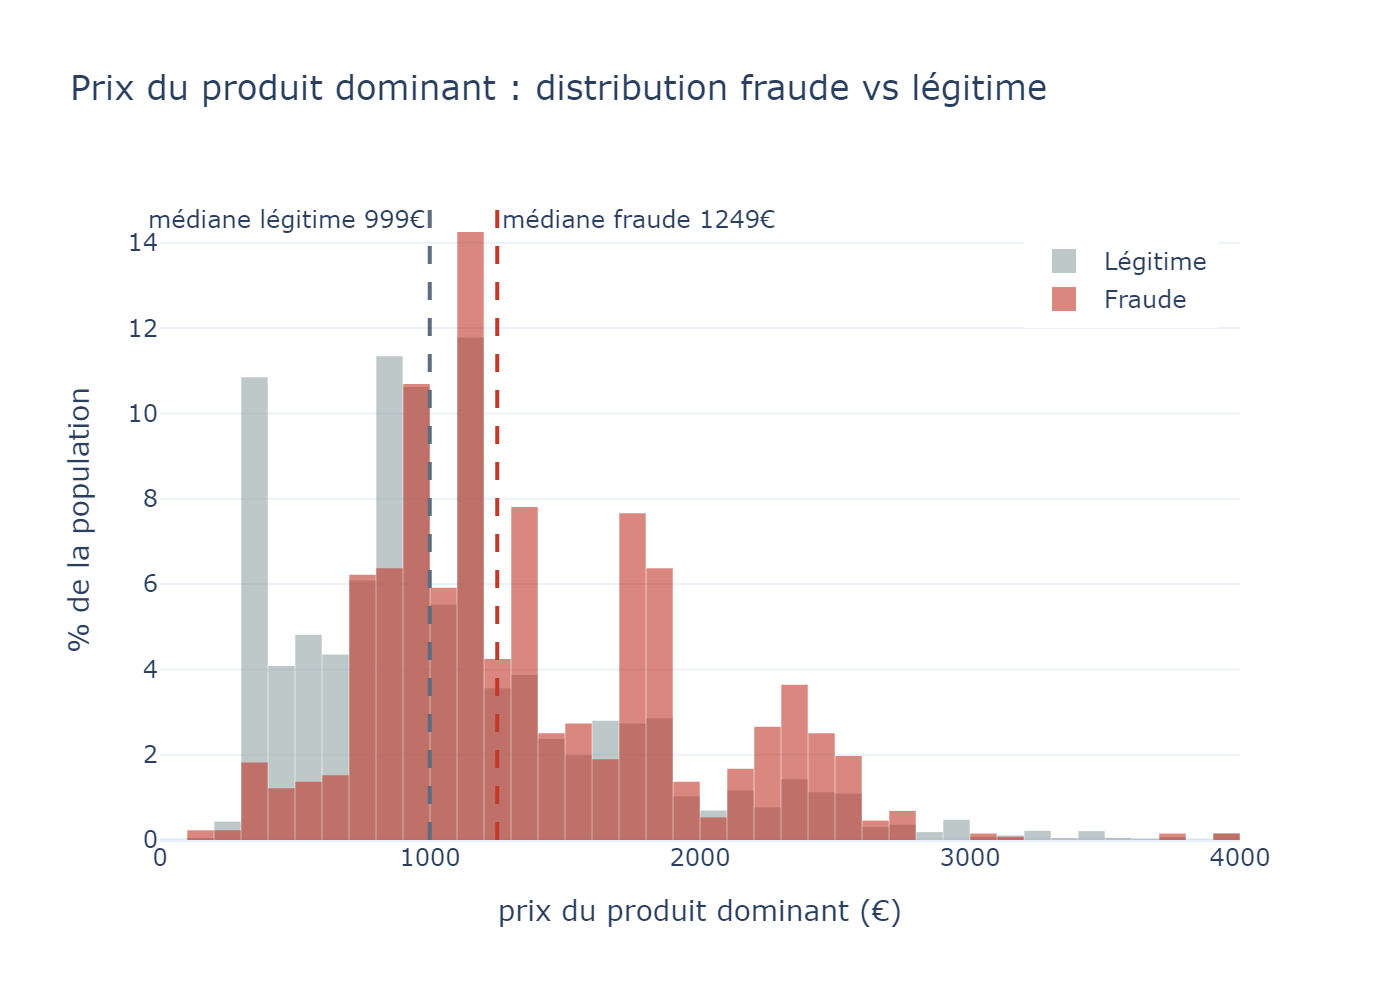

In [3]:
fr = d.loc[d.fraud == 1, "dom_price"]
lg = d.loc[d.fraud == 0, "dom_price"]
XMAX = 4000   # on cadre la vue (queue au-delà rare) ; les médianes sont calculées sur tout

fig = go.Figure()
fig.add_histogram(x=lg, histnorm="percent", name="Légitime", marker_color="#95a5a6",
                  opacity=0.6, xbins=dict(start=0, size=100))
fig.add_histogram(x=fr, histnorm="percent", name="Fraude", marker_color="#c0392b",
                  opacity=0.6, xbins=dict(start=0, size=100))
fig.add_vline(x=lg.median(), line_dash="dash", line_color="#5d6d7e",
              annotation_text=f"médiane légitime {lg.median():.0f}€", annotation_position="top left")
fig.add_vline(x=fr.median(), line_dash="dash", line_color="#c0392b",
              annotation_text=f"médiane fraude {fr.median():.0f}€", annotation_position="top right")
fig.update_layout(barmode="overlay", template="plotly_white", bargap=0.02,
    title="Prix du produit dominant : distribution fraude vs légitime",
    xaxis_title="prix du produit dominant (€)", yaxis_title="% de la population",
    xaxis_range=[0, XMAX], legend=dict(x=0.8, y=0.95))
show_fig(fig, "prix_distribution")

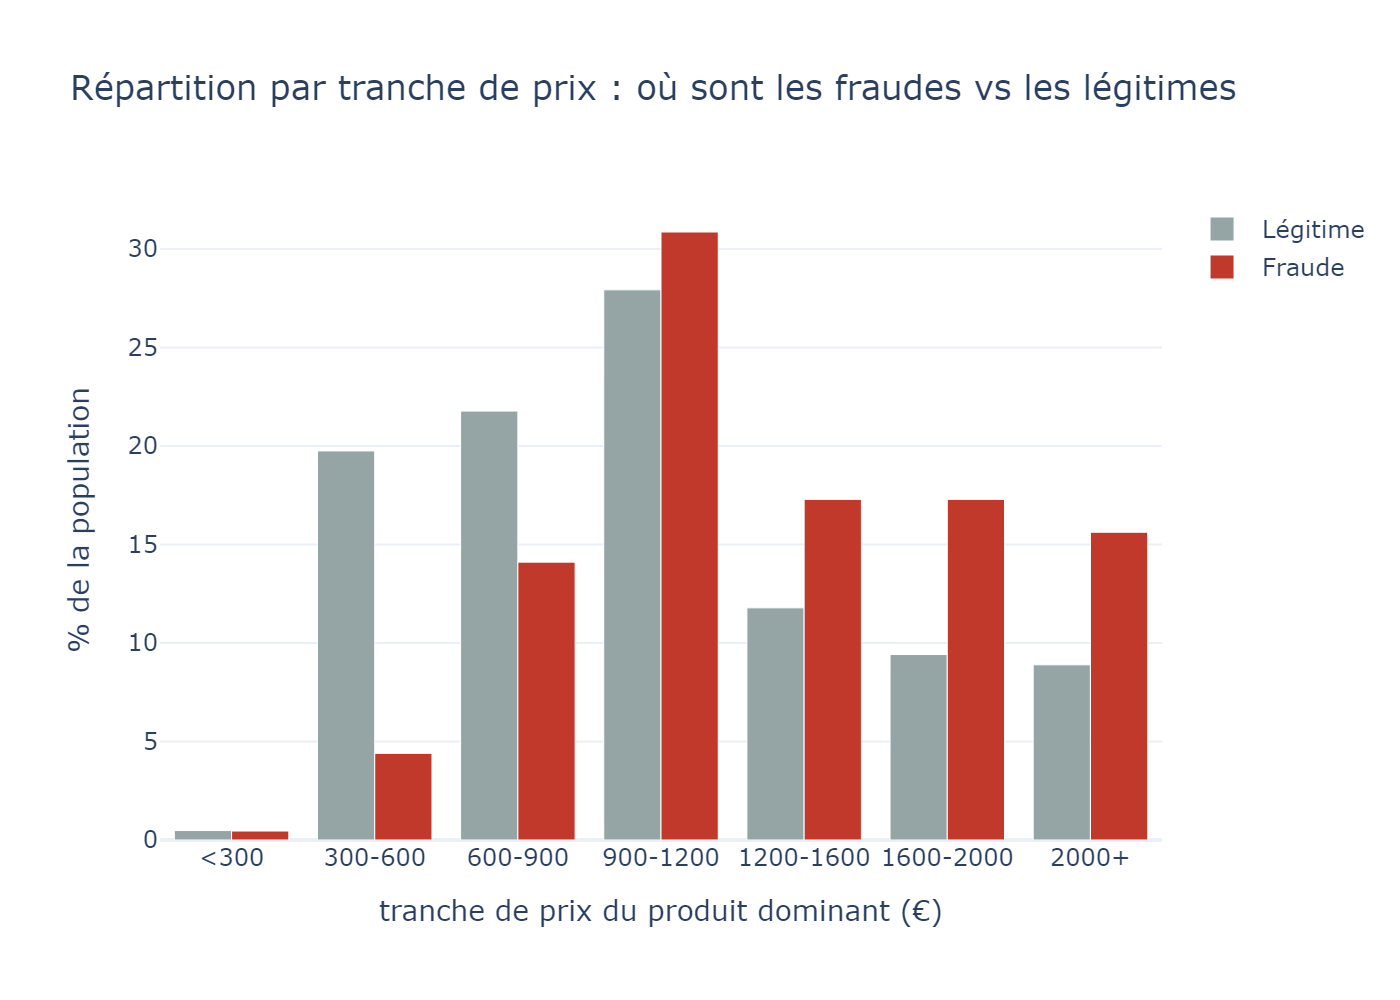

,% légitimes,% fraudes
band,,
<300,0.5,0.5
300-600,19.7,4.4
600-900,21.8,14.1
900-1200,27.9,30.9
1200-1600,11.8,17.3
1600-2000,9.4,17.3
2000+,8.9,15.6


In [4]:
# Même information par tranches de prix (plus facile à lire)
bands = [0, 300, 600, 900, 1200, 1600, 2000, np.inf]
labs  = ["<300", "300-600", "600-900", "900-1200", "1200-1600", "1600-2000", "2000+"]
d["band"] = pd.cut(d.dom_price, bands, labels=labs, right=False)

t = d.groupby("band").agg(nf=("fraud", "sum"), n=("fraud", "size"))
t["% légitimes"] = 100 * (t.n - t.nf) / (t.n - t.nf).sum()
t["% fraudes"]   = 100 * t.nf / t.nf.sum()

fig2 = go.Figure()
fig2.add_bar(x=labs, y=t["% légitimes"], name="Légitime", marker_color="#95a5a6")
fig2.add_bar(x=labs, y=t["% fraudes"],   name="Fraude",   marker_color="#c0392b")
fig2.update_layout(barmode="group", template="plotly_white",
    title="Répartition par tranche de prix : où sont les fraudes vs les légitimes",
    xaxis_title="tranche de prix du produit dominant (€)", yaxis_title="% de la population")
show_fig(fig2, "prix_tranches")

display(t[["% légitimes", "% fraudes"]].round(1))

### Ce qu'on voit

- **En bas de gamme, presque pas de fraude.** Sous 600 €, on trouve ~20 % des
  paniers *légitimes* mais seulement ~5 % des *fraudes*. Acheter pas cher, c'est
  presque toujours honnête.
- **Les deux courbes se croisent vers 900–1200 €** : c'est la frontière du
  « territoire suspect ».
- **En haut de gamme, la fraude domine.** Au-dessus de 1600 €, il y a environ
  **deux fois plus** de fraudes que de légitimes (en proportion).
- La **moitié des fraudes dépassent 1249 €**, contre **999 €** pour les légitimes.

### Ce que ça veut dire

La fraude vise des produits **chers**, ce qui est logique quand le but est de **revendre**.
Concrètement, le prix permet de **trier les commandes**, dans les deux sens :

- **Pas cher → on peut laisser passer.** Un panier à 400 € est presque toujours
  honnête (5 % des fraudes seulement). Inutile d'y consacrer des vérifications :
  on gagne du temps sans rater grand-chose.
- **Cher → on regarde de près.** Au-dessus de 1600 €, la fraude est deux fois plus
  présente. C'est là qu'on concentre les contrôles.

> **En clair :** sur 1 000 commandes, l'essentiel de la fraude se cache dans les
> quelques centaines les plus chères. Surveiller celles-là et laisser filer les
> moins chères, c'est attraper beaucoup de fraude pour peu d'effort.

> ⚠️ Vue *marginale* : on mélange ici toutes les catégories (un ordinateur et un
> téléviseur à 1 800 € n'ont pas le même risque). Les analyses suivantes
> affineront ce que le prix seul ne dit pas.


## Le taux de fraude selon le prix (la « courbe de risque »)

La distribution ci-dessus comparait deux populations ; ici on répond à la question de terrain : **à un prix
donné, quelle est la probabilité de fraude ?**

Pour chaque tranche de prix, on calcule le **% de paniers frauduleux**. On trace
la courbe **séparément** pour les paniers **mono** (1 bien) et **multi** (2 biens
et +) : si le risque monte avec le prix **dans les deux cas**, c'est bien le
**prix** qui joue, pas la taille du panier.


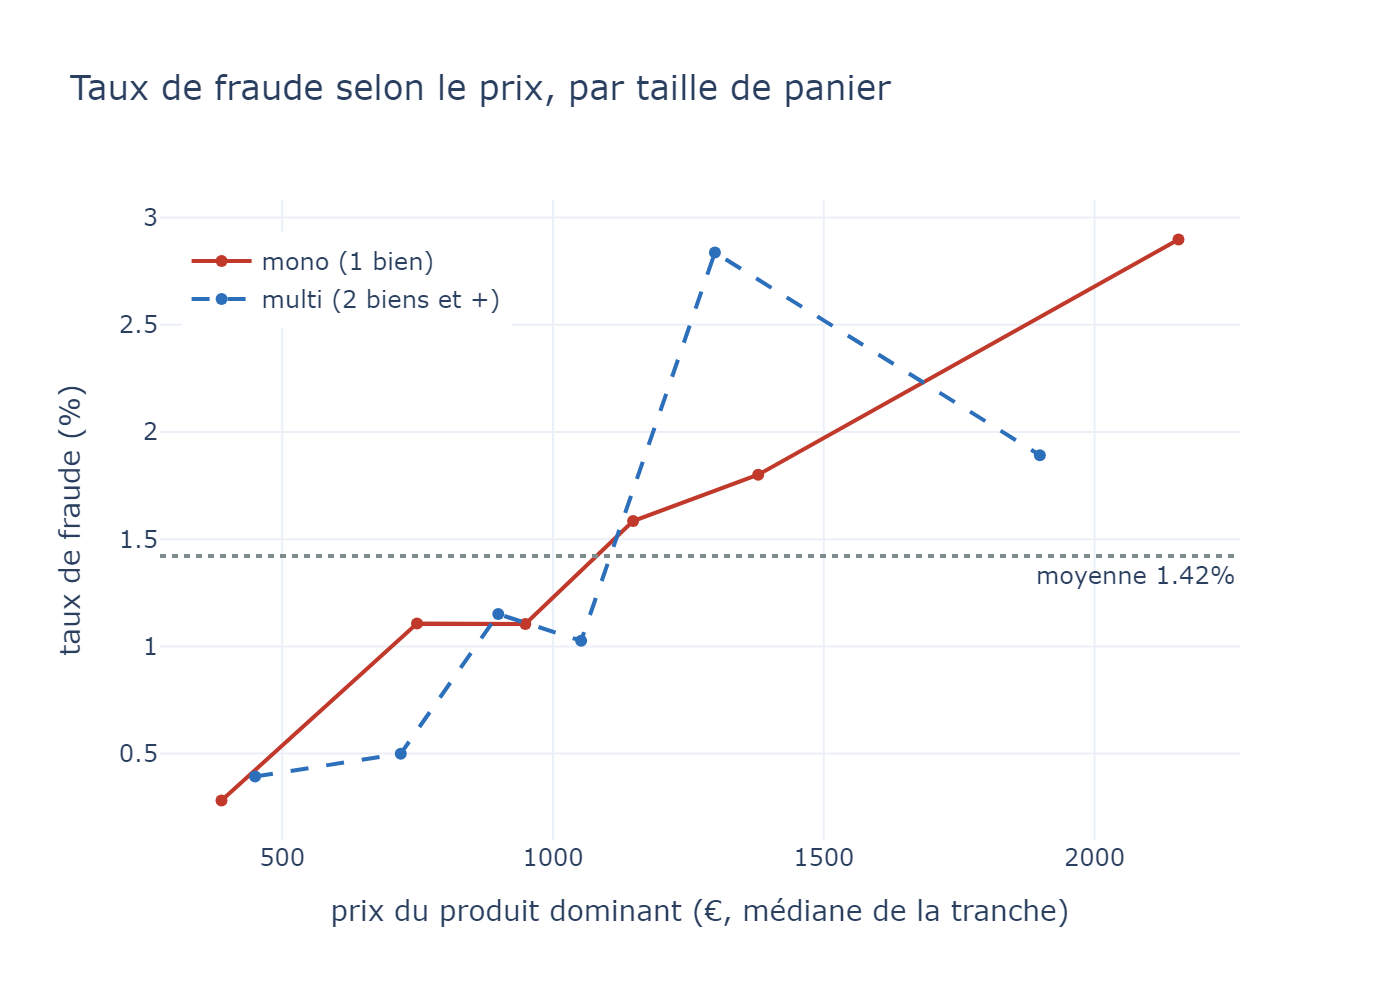

In [5]:
def taux_par_prix(sub, nq=6):
    s = sub.copy()
    s["q"] = pd.qcut(s.dom_price, nq, duplicates="drop")
    return s.groupby("q").agg(tx=("fraud", "mean"), med=("dom_price", "median"), n=("fraud", "size"))

mono  = taux_par_prix(d[d.taille == 1])
multi = taux_par_prix(d[d.taille >= 2])

fig = go.Figure()
fig.add_scatter(x=mono.med, y=mono.tx * 100, mode="lines+markers", name="mono (1 bien)",
                line=dict(color="#c0392b", width=2))
fig.add_scatter(x=multi.med, y=multi.tx * 100, mode="lines+markers", name="multi (2 biens et +)",
                line=dict(color="#2c6fbb", width=2, dash="dash"))
fig.add_hline(y=BASE * 100, line_dash="dot", line_color="#7f8c8d",
              annotation_text=f"moyenne {BASE:.2%}", annotation_position="bottom right")
fig.update_layout(template="plotly_white",
    title="Taux de fraude selon le prix, par taille de panier",
    xaxis_title="prix du produit dominant (€, médiane de la tranche)",
    yaxis_title="taux de fraude (%)", legend=dict(x=0.02, y=0.95))
show_fig(fig, "prix_courbe_risque")

### Ce qu'on voit

- Le risque **monte avec le prix dans les deux cas** : les mono de **~0,3 % à ~2,9 %**,
  les multi de **~0,4 % à ~2 %**.
- À prix égal, les paniers **multi sont un peu moins frauduleux** (courbe sous la
  mono) : le gros panier « équipement » est moins ciblé.
- La courbe multi est **plus irrégulière** : normal, il y a 4× moins de paniers
  (18 000 vs 75 000), donc plus de bruit.

### Ce que ça veut dire

- Le risque monte avec le prix **quelle que soit la taille du panier** → c'est bien
  le **prix** qui compte, pas le nombre d'articles. *(C'est le vrai test : comparer
  les mono à « tous les paniers » n'aurait rien prouvé, puisque 80 % des paniers
  sont déjà des mono.)*
- Le taux monte de façon **continue** jusqu'aux prix élevés, sans rupture nette.
  Si les fraudeurs se calaient juste **sous un seuil de contrôle** (au-delà d'un
  certain montant, un financement peut déclencher des vérifications supplémentaires),
  on verrait un pic suivi d'une chute brutale. Ce n'est pas le cas : la fraude semble
  suivre la **valeur de revente** du bien, pas une stratégie d'évitement.
- Enfin, même dans la tranche la plus chère, seulement **~3 % des paniers sont
  frauduleux**, les **97 % restants sont honnêtes**. Le prix dit donc **où**
  chercher (les paniers chers), mais pas **lequel** est frauduleux. Pour
  distinguer la fraude parmi les paniers chers, il faudra regarder **ce qui est
  acheté** : catégorie et marque.


## L'exposition : fraudes en nombre vs en euros

Jusqu'ici on **compte** les fraudes (chacune vaut 1, à 400 € comme à 5 000 €). Ici
on regarde la **perte réelle** : on additionne les **montants**. Pour chaque
tranche de montant total, on compare la **part des fraudes** (en nombre) et la
**part des euros perdus**.


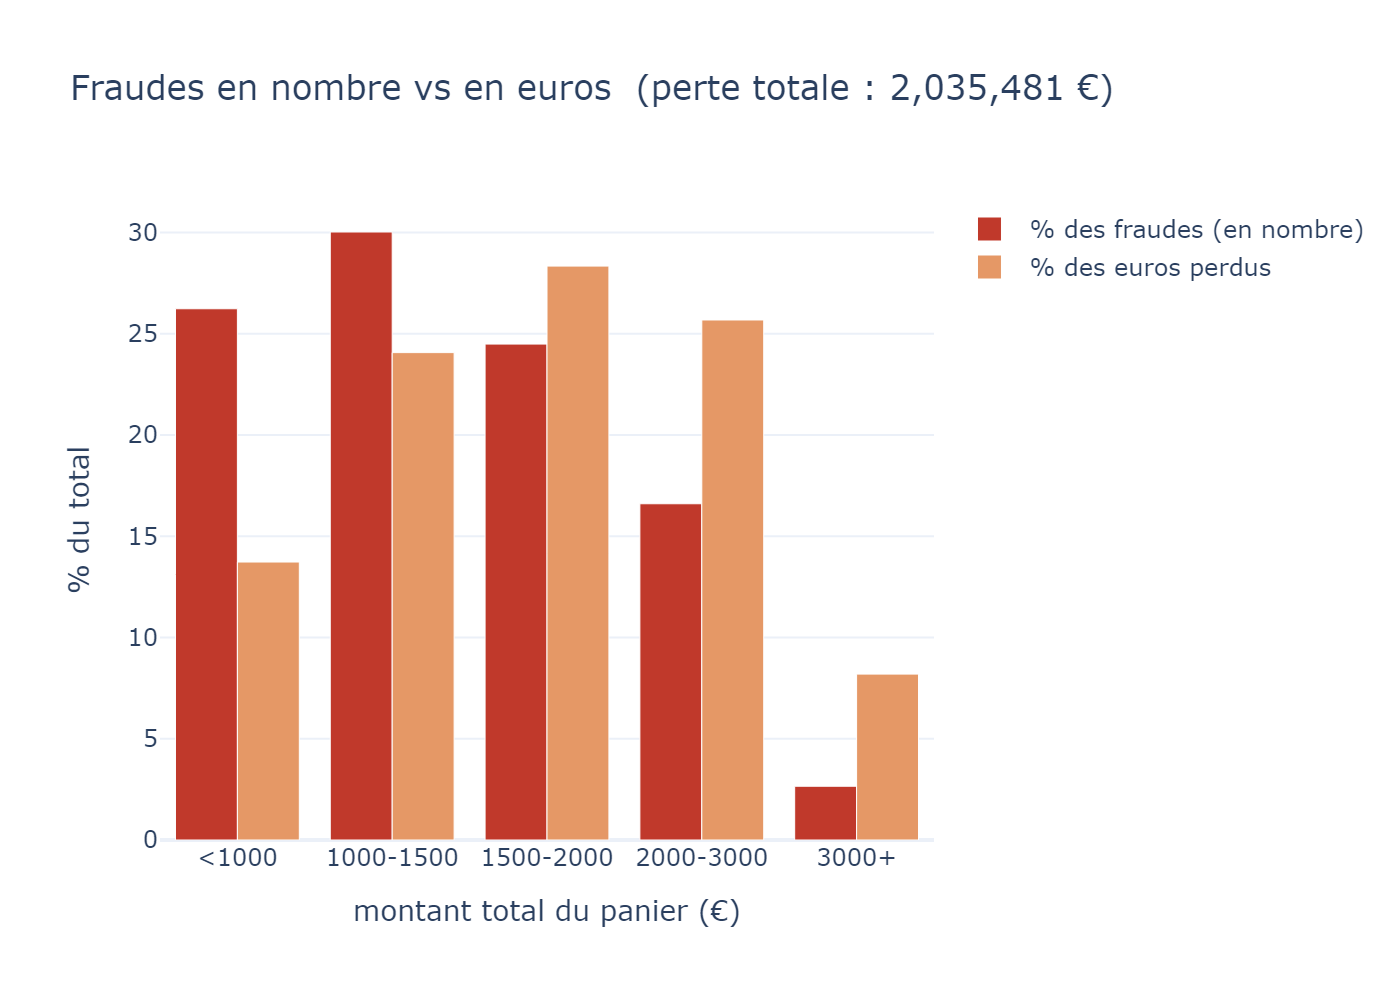

,% des fraudes,% des euros
b,,
<1000,26.2,13.7
1000-1500,30.0,24.1
1500-2000,24.5,28.3
2000-3000,16.6,25.7
3000+,2.7,8.2


In [6]:
frd = d[d.fraud == 1].copy()
bands = [0, 1000, 1500, 2000, 3000, np.inf]
labs  = ["<1000", "1000-1500", "1500-2000", "2000-3000", "3000+"]
frd["b"] = pd.cut(frd.total, bands, labels=labs, right=False)

g = frd.groupby("b").agg(n=("total", "size"), eur=("total", "sum"))
g["% des fraudes"] = 100 * g.n / g.n.sum()
g["% des euros"]   = 100 * g.eur / g.eur.sum()

fig = go.Figure()
fig.add_bar(x=labs, y=g["% des fraudes"], name="% des fraudes (en nombre)", marker_color="#c0392b")
fig.add_bar(x=labs, y=g["% des euros"],   name="% des euros perdus",        marker_color="#e59866")
fig.update_layout(barmode="group", template="plotly_white",
    title=f"Fraudes en nombre vs en euros  (perte totale : {frd.total.sum():,.0f} €)",
    xaxis_title="montant total du panier (€)", yaxis_title="% du total")
show_fig(fig, "prix_exposition")

display(g[["% des fraudes", "% des euros"]].round(1))

### Ce qu'on voit

- Les barres **« euros »** sont **décalées vers les gros montants** par rapport aux
  barres « nombre » : la perte est **plus concentrée en haut** que le nombre de
  fraudes.
- En cumulé : les paniers **> 1500 € = 44 % des fraudes mais 62 % des euros** ; les
  **> 2000 € = 19 % des fraudes mais 34 % des euros**.

### Ce que ça veut dire

- Le métier ne perd pas « des dossiers », il perd **des euros**, et ceux-ci se
  concentrent dans la **minorité de gros paniers**.
- La métrique du challenge (PR-AUC) compte chaque fraude **à égalité** : elle vise
  la **détection**, pas la **perte**. Si l'objectif était de protéger l'argent, il
  faudrait **sur-pondérer les gros paniers**.
- Ceci **clôt le bloc prix**. Le prix a dit *où* chercher et *combien* on perd.
  Place maintenant au **produit** : quelle **catégorie** et quelle **marque**
  distinguent réellement la fraude.


# Le produit ciblé

## La catégorie du produit dominant

> **Le lift** rapporte le taux de fraude d'une catégorie au taux moyen (**1,42 %**) :
> `lift = taux de la catégorie / 1,42 %`. Un lift de **1** = « fraude autant que la
> moyenne », **2** = « deux fois plus », **0,5** = « deux fois moins ». Exemple : la
> téléphonie affiche **2,62 %** de fraude, soit un lift de **1,84**, près du double
> de la moyenne. C'est plus lisible qu'un taux brut, qui obligerait à comparer
> mentalement des « 2,62 % » à des « 0,35 % ».

Deux informations d'un coup d'œil :
- **à gauche** : le **lift de fraude** par catégorie (sur le train) : quelles
  catégories sont sur- ou sous-représentées dans la fraude ;
- **à droite** : l'**écart de composition** train − test (en points de %) par
  catégorie. S'il est proche de **0** partout, les deux échantillons ont la
  **même composition** (sinon, le signal appris sur le train ne transférerait pas
  au test). Cet écart reste lisible même pour les petites catégories, là où des
  parts brutes seraient écrasées par `COMPUTERS` (53 %).


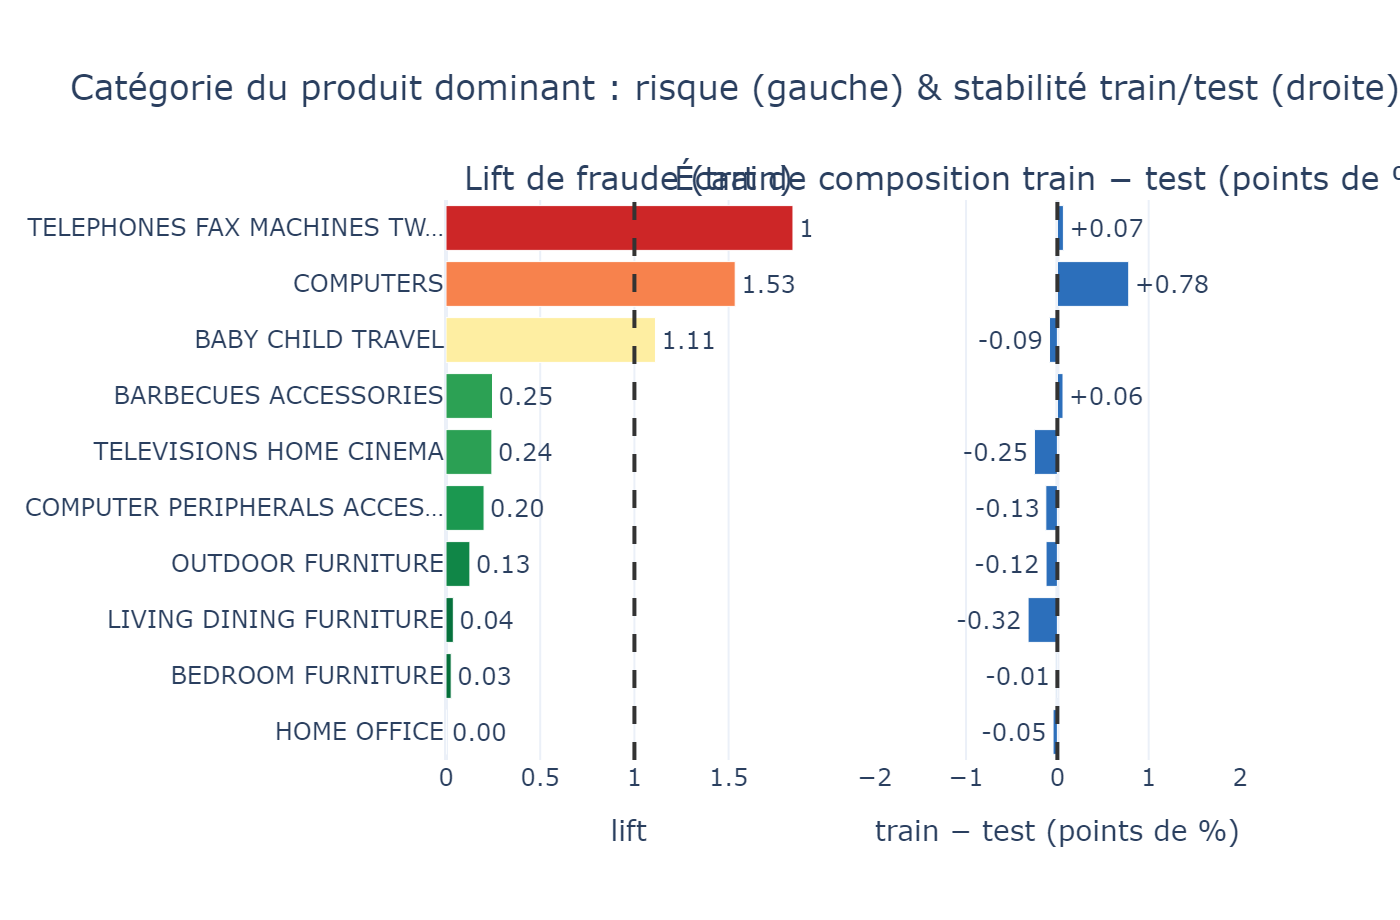

In [7]:
MIN_N = 200
cat = d.groupby("dom_cat").agg(n=("fraud", "size"), tx=("fraud", "mean"))
cat["lift"] = cat.tx / BASE
cat = cat[cat.n >= MIN_N].sort_values("lift")          # bas -> haut
cats = cat.index.tolist()
ylab = [c[:26] + "…" if len(c) > 26 else c for c in cats]

# écart de composition train - test (points de %), sur les mêmes catégories
sh_tr = 100 * d.dom_cat.value_counts(normalize=True).reindex(cats).fillna(0)
sh_te = 100 * d_te.dom_cat.value_counts(normalize=True).reindex(cats).fillna(0)
ecart = sh_tr - sh_te

fig = make_subplots(rows=1, cols=2, shared_yaxes=True, horizontal_spacing=0.08,
    subplot_titles=("Lift de fraude (train)", "Écart de composition train − test (points de %)"))

# gauche : lift, couleur centrée sur 1 (rouge > 1, vert < 1)
fig.add_bar(y=ylab, x=cat.lift, orientation="h", row=1, col=1, showlegend=False,
            marker=dict(color=cat.lift, colorscale="RdYlGn_r", cmin=0, cmax=2, cmid=1),
            text=[f"{v:.2f}" for v in cat.lift], textposition="outside")
fig.add_vline(x=1, line_dash="dash", line_color="#333", row=1, col=1)

# droite : écart train-test ; proche de 0 partout = même composition
fig.add_bar(y=ylab, x=ecart.values, orientation="h", row=1, col=2, showlegend=False,
            marker_color="#2c6fbb", text=[f"{v:+.2f}" for v in ecart.values], textposition="outside")
fig.add_vline(x=0, line_dash="dash", line_color="#333", row=1, col=2)

fig.update_layout(template="plotly_white", height=max(420, 46 * len(cats)),
    title="Catégorie du produit dominant : risque (gauche) & stabilité train/test (droite)")
fig.update_xaxes(title_text="lift", row=1, col=1)
fig.update_xaxes(title_text="train − test (points de %)", row=1, col=2, range=[-2, 2])
show_fig(fig, "produit_categorie")

### Ce qu'on voit

**Une base très concentrée.** Seules **10 catégories** dépassent 200 paniers en
produit dominant, et `COMPUTERS` à lui seul fait **53 %** des paniers.

**Le risque (gauche).**
- **Sur-risque** : `TELEPHONES` (lift **1,84**) et `COMPUTERS` (**1,53**), soit l'électronique. `BABY CHILD TRAVEL` est un peu au-dessus (1,11).
- **Fort sous-risque** : `TELEVISIONS` (0,24), `COMPUTER PERIPHERALS` (0,20),
  meubles (0,03–0,13), `HOME OFFICE` (0,00) : quasi aucune fraude, malgré de gros
  volumes (TV = 16 %, périphériques = 14 %).

**La stabilité (droite).** Les écarts train − test sont **tous proches de 0**
(≤ 1 point de %) → **même composition**, aucun décalage entre les deux échantillons.

### Ce que ça veut dire

- La fraude vise l'**électronique portable et revendable** (téléphones, ordinateurs).
- Le **pouvoir d'exclusion** est énorme : téléviseurs et meubles pèsent lourd en
  volume avec **presque zéro fraude** → on peut les écarter de façon fiable (ça
  aide autant que le sur-risque).
- Cas parlant : le **téléviseur** est cher et théoriquement revendable, mais très
  peu frauduleux (0,24), sans doute **trop encombrant** pour être écoulé. Cher ne
  suffit donc pas : le bien doit aussi être **liquide**.
- **Train et test identiques** → le signal trouvé sur le train **transférera** au test.

> Deux réserves honnêtes : (1) `COMPUTERS` a un lift modeste (1,53) mais 53 % du
> volume → c'est un filtre **large**, pas tranchant ; (2) ce lift reste **confondu
> avec le prix** (l'électronique est chère) : le démêlage viendra. Et dans une
> catégorie, c'est souvent la **marque** qui affine (ex. Silver Cross en
> puériculture) → c'est l'objet de la **section suivante, la marque**.


## La marque du produit dominant

Même lecture que pour la catégorie, mais sur la **marque** : lift de fraude à gauche, écart de
composition train − test à droite. La marque **resserre** ce que la catégorie
laisse flou. (Seuil de volume abaissé à 100 pour ne pas rater les marques petites
mais nettes, comme les poussettes premium.)


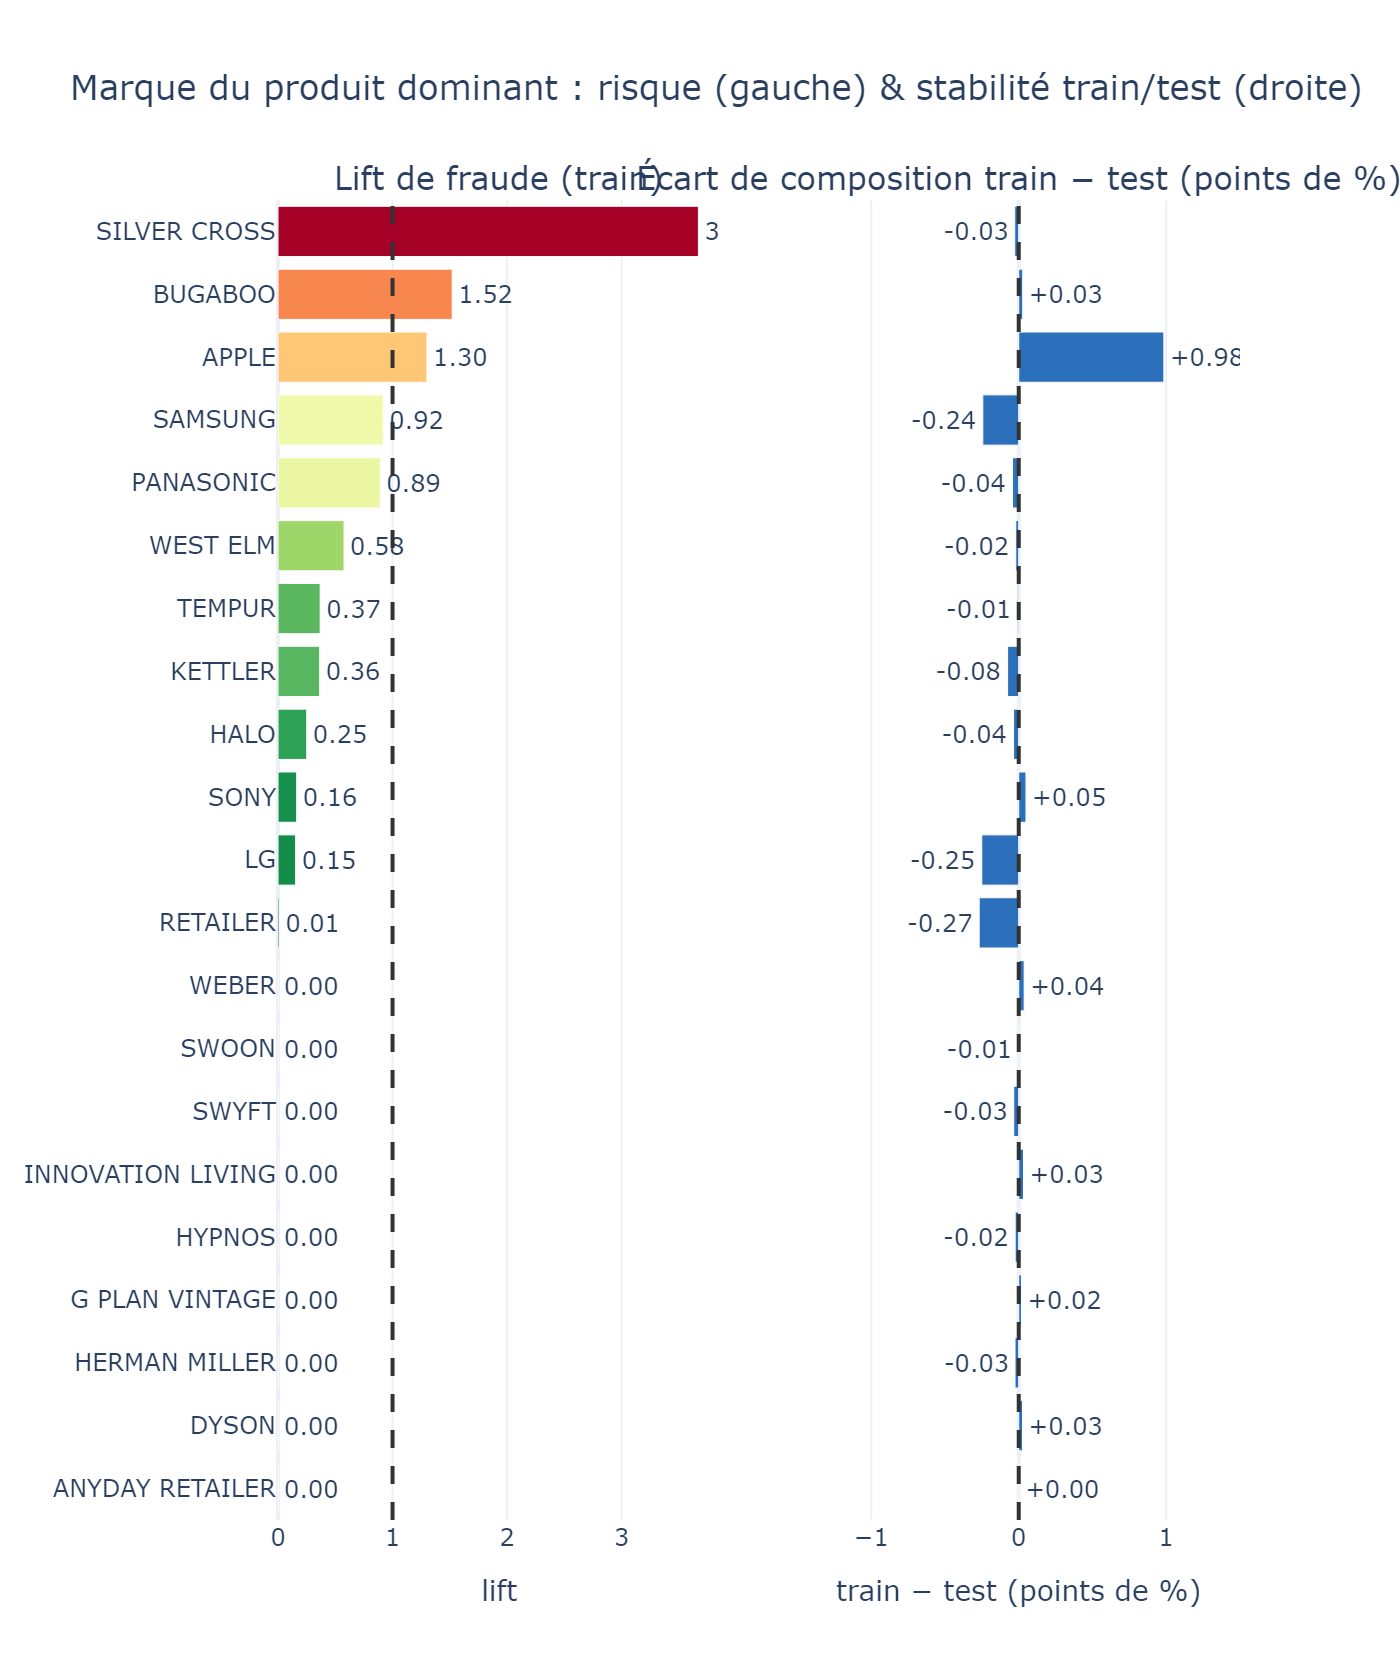

In [8]:
MIN_N_MK = 100
mk = d.groupby("dom_make").agg(n=("fraud", "size"), tx=("fraud", "mean"))
mk["lift"] = mk.tx / BASE
mk = mk[mk.n >= MIN_N_MK].sort_values("lift")
mks = mk.index.tolist()
ylab = [m[:22] + "…" if len(m) > 22 else m for m in mks]

sh_tr = 100 * d.dom_make.value_counts(normalize=True).reindex(mks).fillna(0)
sh_te = 100 * d_te.dom_make.value_counts(normalize=True).reindex(mks).fillna(0)
ecart = sh_tr - sh_te

fig = make_subplots(rows=1, cols=2, shared_yaxes=True, horizontal_spacing=0.08,
    subplot_titles=("Lift de fraude (train)", "Écart de composition train − test (points de %)"))

fig.add_bar(y=ylab, x=mk.lift, orientation="h", row=1, col=1, showlegend=False,
            marker=dict(color=mk.lift, colorscale="RdYlGn_r", cmin=0, cmax=2, cmid=1),
            text=[f"{v:.2f}" for v in mk.lift], textposition="outside")
fig.add_vline(x=1, line_dash="dash", line_color="#333", row=1, col=1)

fig.add_bar(y=ylab, x=ecart.values, orientation="h", row=1, col=2, showlegend=False,
            marker_color="#2c6fbb", text=[f"{v:+.2f}" for v in ecart.values], textposition="outside")
fig.add_vline(x=0, line_dash="dash", line_color="#333", row=1, col=2)

fig.update_layout(template="plotly_white", height=max(420, 40 * len(mks)),
    title="Marque du produit dominant : risque (gauche) & stabilité train/test (droite)")
fig.update_xaxes(title_text="lift", row=1, col=1)
fig.update_xaxes(title_text="train − test (points de %)", row=1, col=2, range=[-1.5, 1.5])
show_fig(fig, "produit_marque")

### Ce qu'on voit

- **Trois marques seulement au-dessus de la moyenne** : `SILVER CROSS` (lift
  **3,67**, poussettes), `BUGABOO` (**1,52**, poussettes) et `APPLE` (**1,30**).
- `APPLE` pèse **70 % des biens**, encore plus concentré que `COMPUTERS` (53 %).
- **Surprise** : `SAMSUNG` (0,92) et `SONY` (0,16) sont **sous** la moyenne. Ce
  n'est donc pas « l'électronique » en général qui est ciblée, c'est
  **spécifiquement Apple**.
- **Fort sous-risque** : `DYSON`, `WEBER`, marques de meuble, et le générique
  `ANYDAY RETAILER` : **0 fraude**.
- **Train et test** : écarts tous proches de 0 → même composition.

### Ce que ça veut dire

- La marque **révèle une cible que la catégorie cachait** : la **puériculture
  premium** (Silver Cross, Bugaboo), invisible au niveau de la catégorie (à 1,11).
- Elle **tranche à l'intérieur de l'électronique** : Apple oui, Samsung / Sony non.
  La catégorie « ordinateurs / téléphones » ne le voyait pas ; la marque, si.
- Fil rouge : Apple et les poussettes premium sont des biens **chers, désirables et
  faciles à revendre**.

> Mêmes réserves : `APPLE` = **large mais peu tranchant** (70 % du volume, lift
> 1,30) ; `SILVER CROSS` = **tranchant mais fragile** (lift 3,67 sur n≈115) ; et
> tout ceci reste **confondu avec le prix**.


## Concentration des produits (`goods_code`)

On descend au **produit exact** (le SKU). La fraude tient-elle sur **une poignée de
produits « chauds »**, ou est-elle **étalée** sur beaucoup de références ?

**Courbe de Lorenz** : on trie les produits du plus fréquent au moins fréquent et on
cumule. Une courbe qui **monte vite** = concentré ; proche de la **diagonale** =
diffus. On compare les **fraudes** (rouge) à **l'ensemble des paniers** (gris), pour
voir si la fraude est *plus* concentrée que les achats en général.


1319 fraudes réparties sur 236 produits (SKU) distincts
top 20 SKU = 59% des fraudes | top 50 = 76%


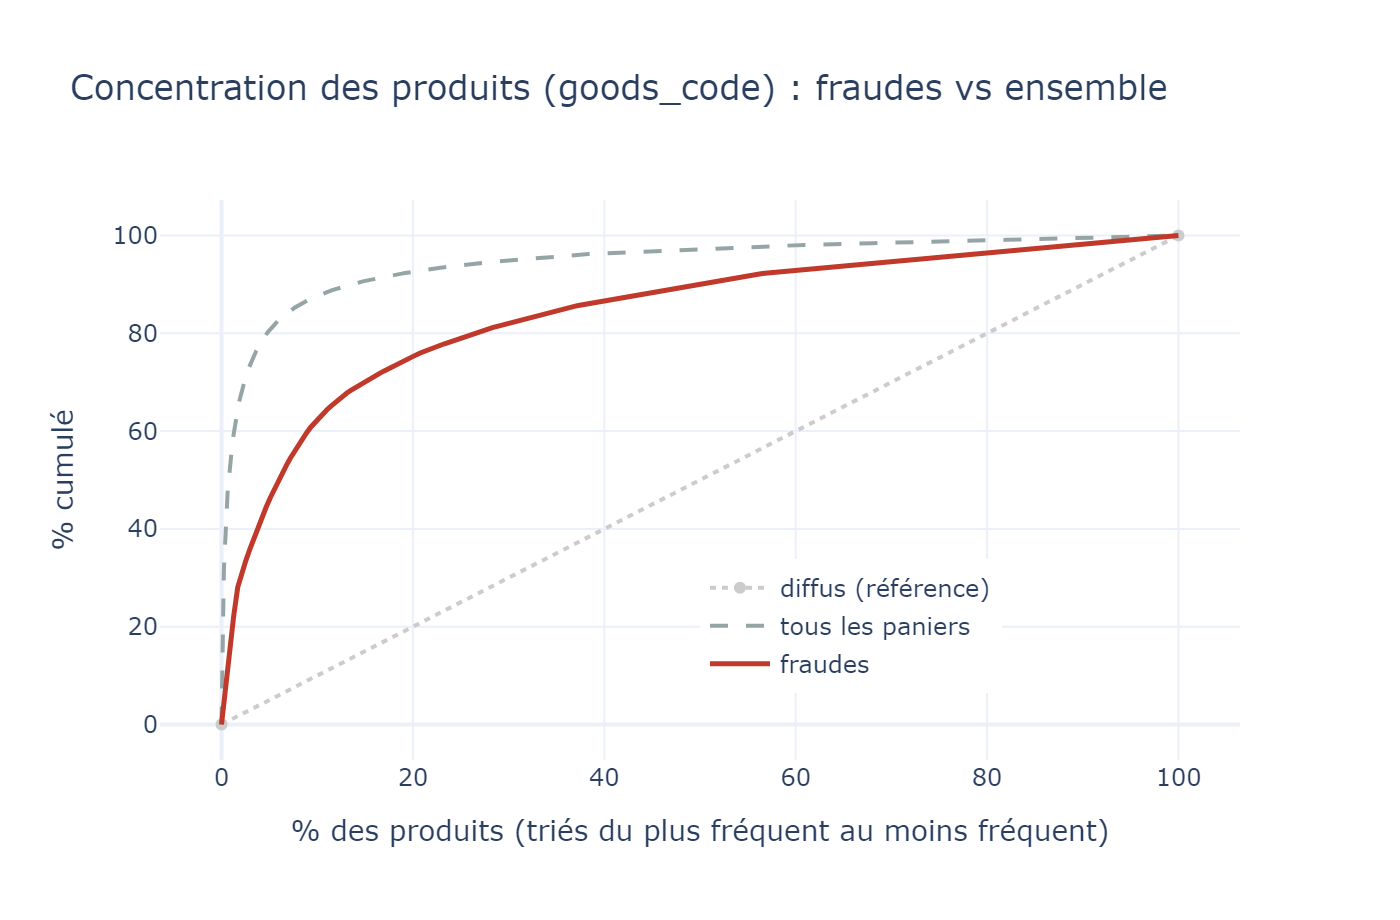

In [9]:
def lorenz(codes):
    vc = pd.Series(codes).value_counts().values
    y = np.concatenate([[0], np.cumsum(vc) / vc.sum()]) * 100
    x = np.concatenate([[0], np.arange(1, len(vc) + 1) / len(vc)]) * 100
    return x, y

xf, yf = lorenz(d.loc[d.fraud == 1, "dom_code"])
xa, ya = lorenz(d["dom_code"])

vcf = d.loc[d.fraud == 1, "dom_code"].value_counts()
print(f"{int(d.fraud.sum())} fraudes réparties sur {len(vcf)} produits (SKU) distincts")
print(f"top 20 SKU = {100*vcf.head(20).sum()/vcf.sum():.0f}% des fraudes | "
      f"top 50 = {100*vcf.head(50).sum()/vcf.sum():.0f}%")

fig = go.Figure()
fig.add_scatter(x=[0, 100], y=[0, 100], name="diffus (référence)",
                line=dict(color="#cccccc", dash="dot"))
fig.add_scatter(x=xa, y=ya, name="tous les paniers", line=dict(color="#95a5a6", width=2, dash="dash"))
fig.add_scatter(x=xf, y=yf, name="fraudes", line=dict(color="#c0392b", width=2.5))
fig.update_layout(template="plotly_white", height=460,
    title="Concentration des produits (goods_code) : fraudes vs ensemble",
    xaxis_title="% des produits (triés du plus fréquent au moins fréquent)",
    yaxis_title="% cumulé", legend=dict(x=0.5, y=0.12))
show_fig(fig, "produit_concentration")

### Ce qu'on voit

- **En absolu, la fraude est concentrée** : 1 319 fraudes réparties sur seulement
  **236 produits**, dont les **top 50 SKU portent 76 %** (top 20 → 59 %). Il existe
  bien une « liste » de produits récurrents.
- **Mais relativement, elle est *moins* concentrée que les achats** : le top 1 % des
  produits fait **55 % des achats** mais seulement **16 % des fraudes** (Gini **0,69**
  pour la fraude vs **0,89** pour l'ensemble). La courbe rouge est **sous** la grise.

### Ce que ça veut dire

- Ce n'est **pas** « 5 produits = toute la fraude ». La fraude ne se rue pas sur *le*
  produit le plus vendu, elle s'étale sur un **large éventail de biens chers et
  liquides** (nombreuses variantes de MacBook / iPhone / iPad, poussettes…).
- La cible n'est donc pas un **SKU précis**, c'est un **type de bien** (cher × liquide,
  cf. les confondants plus loin). Le produit exact compte moins que sa **nature**.

> Implication modélisation : un encodage par `goods_code` **aide** (les taux par SKU
> diffèrent), mais **ne sera pas un signal miracle** : la fraude est trop étalée sur
> les SKU. Le gros du signal reste au niveau **prix × catégorie/liquidité**.


# Démêler le produit du prix (les confondants)

L'analyse par catégorie et par marque a un angle mort : l'électronique et Apple sont **chers**, et on sait que
cher = risqué. Alors « Apple / l'électronique risqués », est-ce **le produit**
ou **le prix** ? On **compare à prix égal** : dans une même tranche de prix, la
catégorie (puis la marque) change-t-elle encore le taux de fraude ?


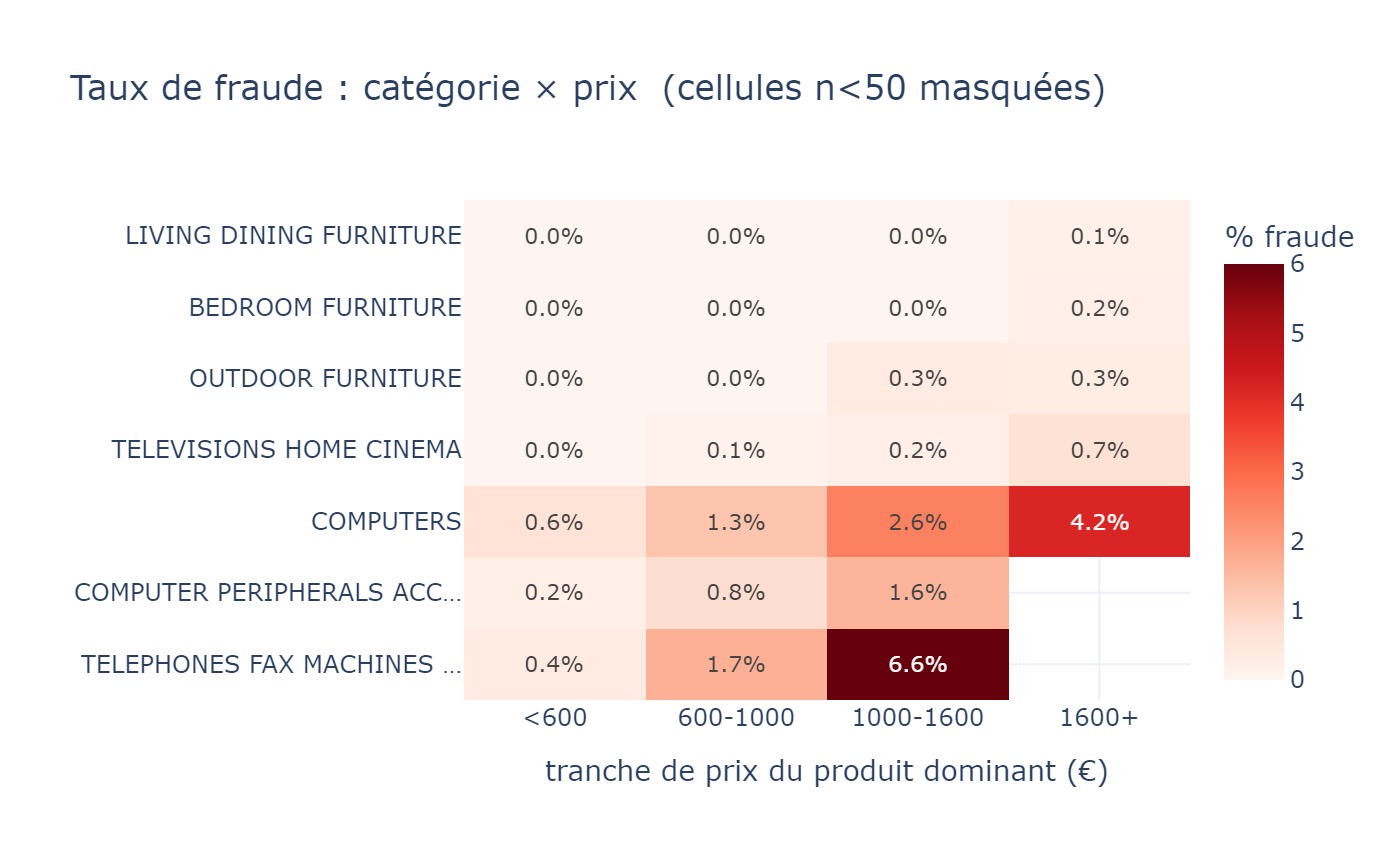

In [10]:
bands = [0, 600, 1000, 1600, np.inf]
labs  = ["<600", "600-1000", "1000-1600", "1600+"]
top = d.dom_cat.value_counts().head(7).index.tolist()

tmp = d[d.dom_cat.isin(top)].copy()
tmp["pb"] = pd.cut(tmp.dom_price, bands, labels=labs, right=False)
rate = tmp.pivot_table("fraud", "dom_cat", "pb", aggfunc="mean") * 100
vol  = tmp.pivot_table("fraud", "dom_cat", "pb", aggfunc="size")
order = rate.mean(axis=1).sort_values(ascending=False).index.tolist()
rate, vol = rate.reindex(order), vol.reindex(order)
Z = rate.where(vol >= 50)                       # masquer les cellules à n < 50
ylab = [c[:24] + "…" if len(c) > 24 else c for c in order]
txt = [["" if pd.isna(Z.loc[c, b]) else f"{Z.loc[c, b]:.1f}%" for b in labs] for c in order]

fig = go.Figure(go.Heatmap(z=Z.values, x=labs, y=ylab, colorscale="Reds", zmin=0, zmax=6,
    text=txt, texttemplate="%{text}", textfont_size=11, colorbar_title="% fraude"))
fig.update_layout(template="plotly_white", height=430,
    title="Taux de fraude : catégorie × prix  (cellules n<50 masquées)",
    xaxis_title="tranche de prix du produit dominant (€)", yaxis_title="")
show_fig(fig, "confondants_categorie_prix")

### Catégorie × prix

- **Une colonne = prix fixé.** À prix égal, les catégories diffèrent énormément :
  à 1000–1600 €, `COMPUTERS` 2,6 % et `TELEPHONES` 6,6 %, mais `TELEVISIONS` 0,2 %
  et meubles ~0 %. → **la catégorie compte au-delà du prix.**
- **Une ligne = catégorie fixée.** Le taux monte avec le prix dans chaque
  catégorie (COMPUTERS 0,6 → 4,2 %). → **le prix compte aussi.**
- **L'exemple qui tranche** : à **1600 €+**, le téléviseur reste à **0,7 %** quand
  l'ordinateur est à **4,2 %** : à prix élevé égal, **6× moins** de fraude. Cher ne
  suffit pas : le bien doit être **liquide** (revendable). TV et meubles, chers mais
  encombrants → épargnés.

→ **Deux leviers réels et partiellement indépendants : le prix ET la nature
(liquide) du produit.**


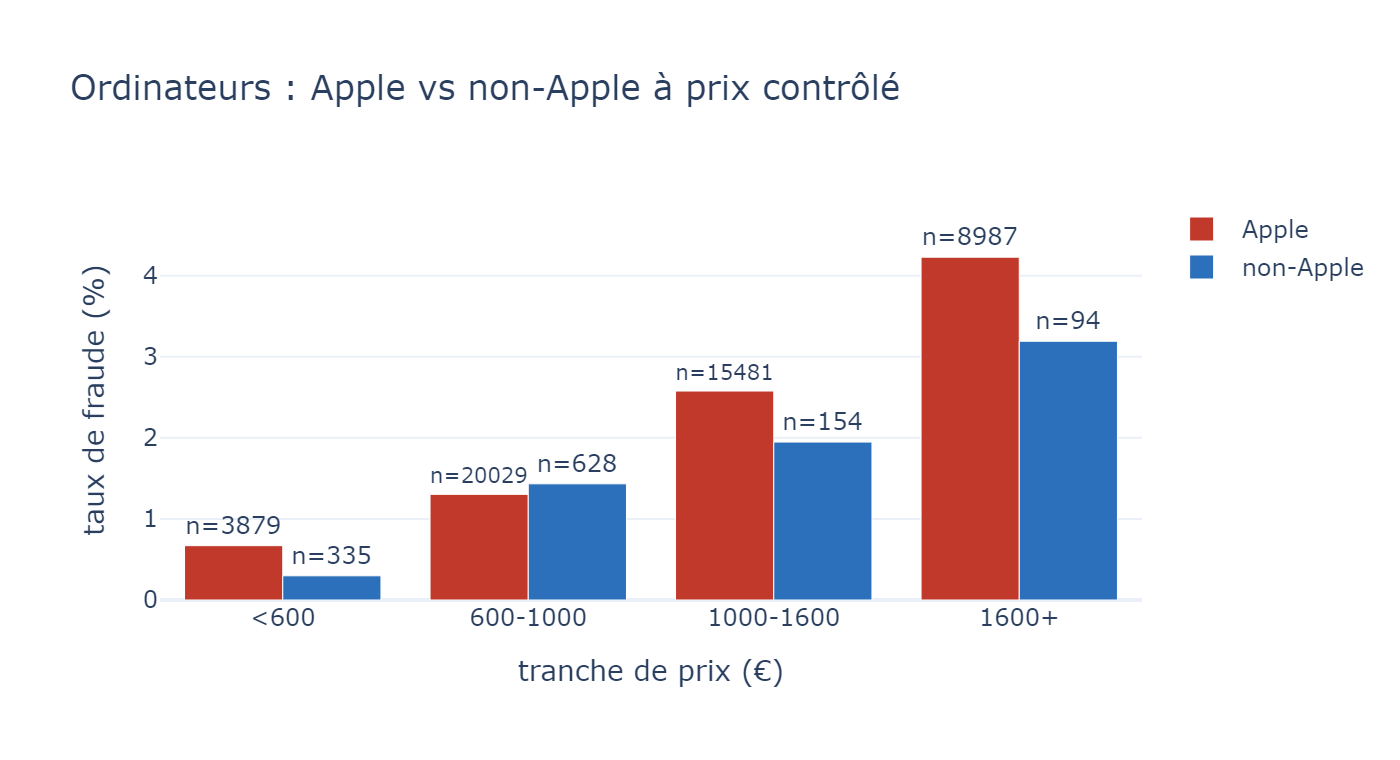

In [11]:
comp = d[d.dom_cat == "COMPUTERS"].copy()
comp["pb"]  = pd.cut(comp.dom_price, bands, labels=labs, right=False)
comp["grp"] = np.where(comp.dom_make == "APPLE", "Apple", "non-Apple")
t = comp.pivot_table("fraud", "grp", "pb", aggfunc="mean") * 100
nn = comp.pivot_table("fraud", "grp", "pb", aggfunc="size")

fig = go.Figure()
for grp, color in [("Apple", "#c0392b"), ("non-Apple", "#2c6fbb")]:
    fig.add_bar(x=labs, y=t.loc[grp, labs].values, name=grp, marker_color=color,
                text=[f"n={int(nn.loc[grp, b])}" for b in labs], textposition="outside")
fig.update_layout(barmode="group", template="plotly_white", height=380,
    title="Ordinateurs : Apple vs non-Apple à prix contrôlé",
    xaxis_title="tranche de prix (€)", yaxis_title="taux de fraude (%)")
show_fig(fig, "confondants_apple")

### Et la marque Apple ?

À l'intérieur des ordinateurs, **à prix égal, Apple ≈ non-Apple** (1000–1600 € :
Apple 2,6 % vs non-Apple 2,0 % ; à 600–1000 € c'est même non-Apple qui dépasse).
Les écarts sont **faibles et instables**, et les non-Apple sont **rares** (n de 90
à 630). → **le lift d'Apple (vu plus haut) vient surtout de ce qu'Apple = ordinateurs et
téléphones chers**, pas d'un effet marque autonome fort.

*(Cohérent avec l'analyse par marque : Samsung et Sony, eux, sont surtout en TV/audio, des
catégories peu frauduleuses, d'où leur lift < 1. La marque reflète surtout la
catégorie et le prix.)*

### Bilan

- La fraude n'est pas « Apple » ni « l'électronique » en soi, c'est le bien
  **cher ET liquide** (portable, revendable) : ordinateurs et téléphones, plus les
  poussettes premium.
- **Prix** et **liquidité du produit** sont les deux moteurs, partiellement
  indépendants ; la **marque** en est surtout le reflet.
- Pour la modélisation : il faut **le prix et la catégorie** (pas seulement la
  marque), et le vrai signal est l'intersection **cher × liquide**.


# La structure du panier : achat ciblé ou revente en volume ?

Non plus *quoi* est acheté, mais *comment* le panier est composé. On teste
l'intuition « le fraudeur achète en gros pour revendre », sur deux axes : la
**taille** du panier et la **quantité** (mêmes articles en plusieurs exemplaires).


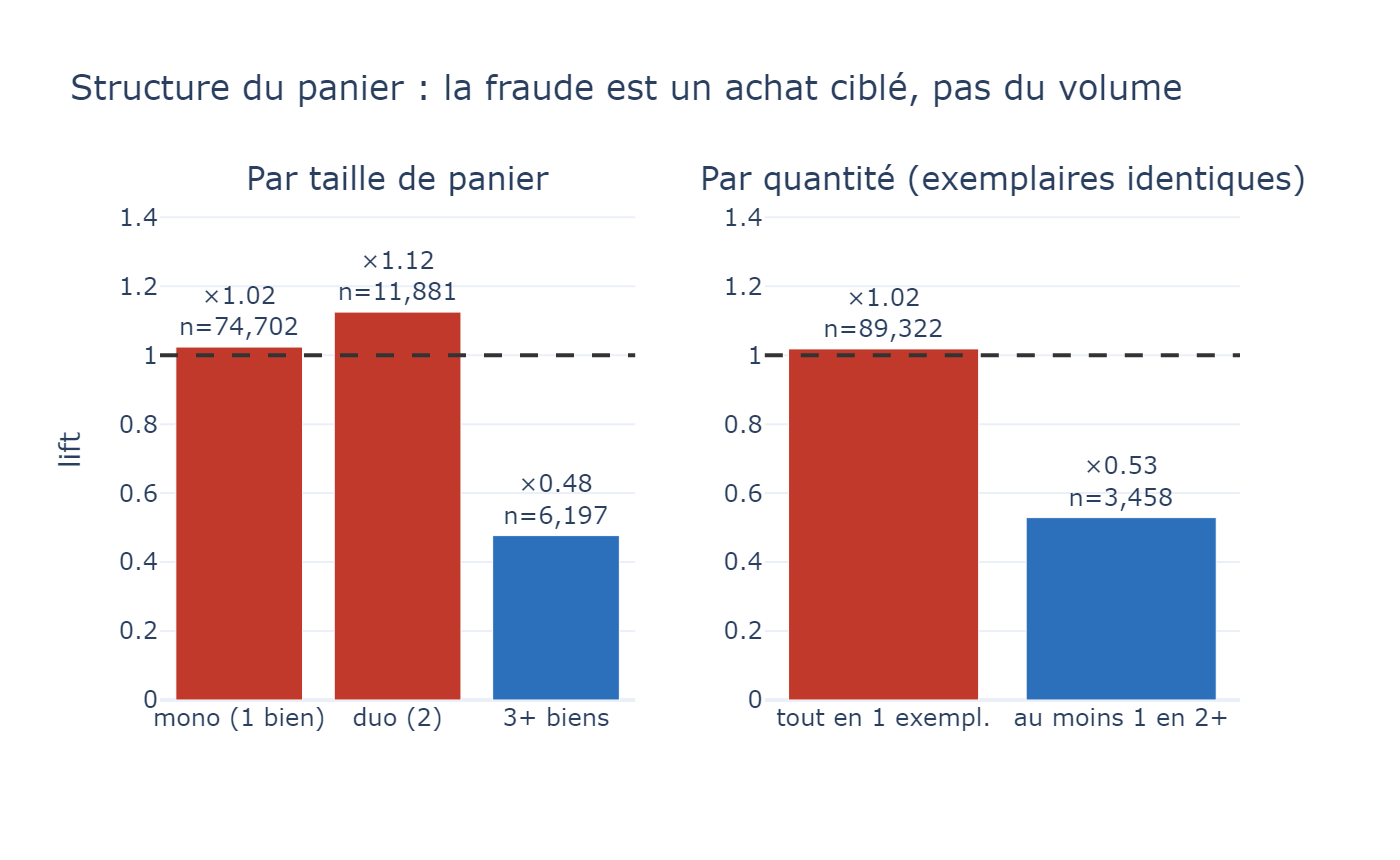

In [12]:
grp_taille = {"mono (1 bien)": d.taille == 1, "duo (2)": d.taille == 2, "3+ biens": d.taille >= 3}
grp_qty    = {"tout en 1 exempl.": d.max_qty <= 1, "au moins 1 en 2+": d.max_qty >= 2}

def lifts(groups):
    labs, lf, ns = [], [], []
    for name, m in groups.items():
        labs.append(name); lf.append(d.fraud[m].mean() / BASE); ns.append(int(m.sum()))
    return labs, lf, ns

fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.12,
    subplot_titles=("Par taille de panier", "Par quantité (exemplaires identiques)"))
for col, groups in enumerate([grp_taille, grp_qty], start=1):
    labs, lf, ns = lifts(groups)
    colors = ["#c0392b" if v >= 1 else "#2c6fbb" for v in lf]
    fig.add_bar(x=labs, y=lf, marker_color=colors, row=1, col=col, showlegend=False,
                text=[f"×{v:.2f}<br>n={n:,}" for v, n in zip(lf, ns)], textposition="outside")
    fig.add_hline(y=1, line_dash="dash", line_color="#333", row=1, col=col)
fig.update_layout(template="plotly_white", height=430,
    title="Structure du panier : la fraude est un achat ciblé, pas du volume")
fig.update_yaxes(title_text="lift", range=[0, 1.45], row=1, col=1)
fig.update_yaxes(range=[0, 1.45], row=1, col=2)
show_fig(fig, "structure_panier")

### Ce qu'on voit

- **La fraude est dans les petits paniers** : mono (80 % des paniers) lift 1,02,
  duo lift 1,12, mais **3+ biens lift 0,48**, soit deux fois moins frauduleux.
- **Les exemplaires multiples sont protecteurs** : acheter au moins un article en
  **2+ exemplaires** → lift **0,53** (sous la moyenne), pas au-dessus.

### Ce que ça veut dire

- **La fraude n'est pas de la revente en volume.** C'est le détournement d'**un seul
  bien**, cher et liquide (cf. les confondants), pas d'un lot.
- Pourquoi le volume est-il *protecteur* ? Acheter 5 fois le même article est un
  **signal d'alerte** que les règles existantes attrapent déjà → ces dossiers sont
  refusés, donc **absents de la base** des financés. Le mode qui *passe*, c'est
  **un objet unique** : assez discret pour être accordé, assez liquide pour être écoulé.

> **Conséquence modélisation** : ne **pas** sur-pondérer les signaux de
> volume/quantité : ici, ils pointent dans le **mauvais sens**.


# Les signaux comportementaux

Non plus *quoi* est acheté (prix, produit), mais **comment** la commande est passée
, ce qui trahit l'intention. Trois signaux : la **garantie**, la **livraison**, la
**marque nommée vs générique**. Leur intérêt : ce sont des axes **différents** du
prix et du produit : du signal qui s'**ajoute**, au lieu de se répéter.


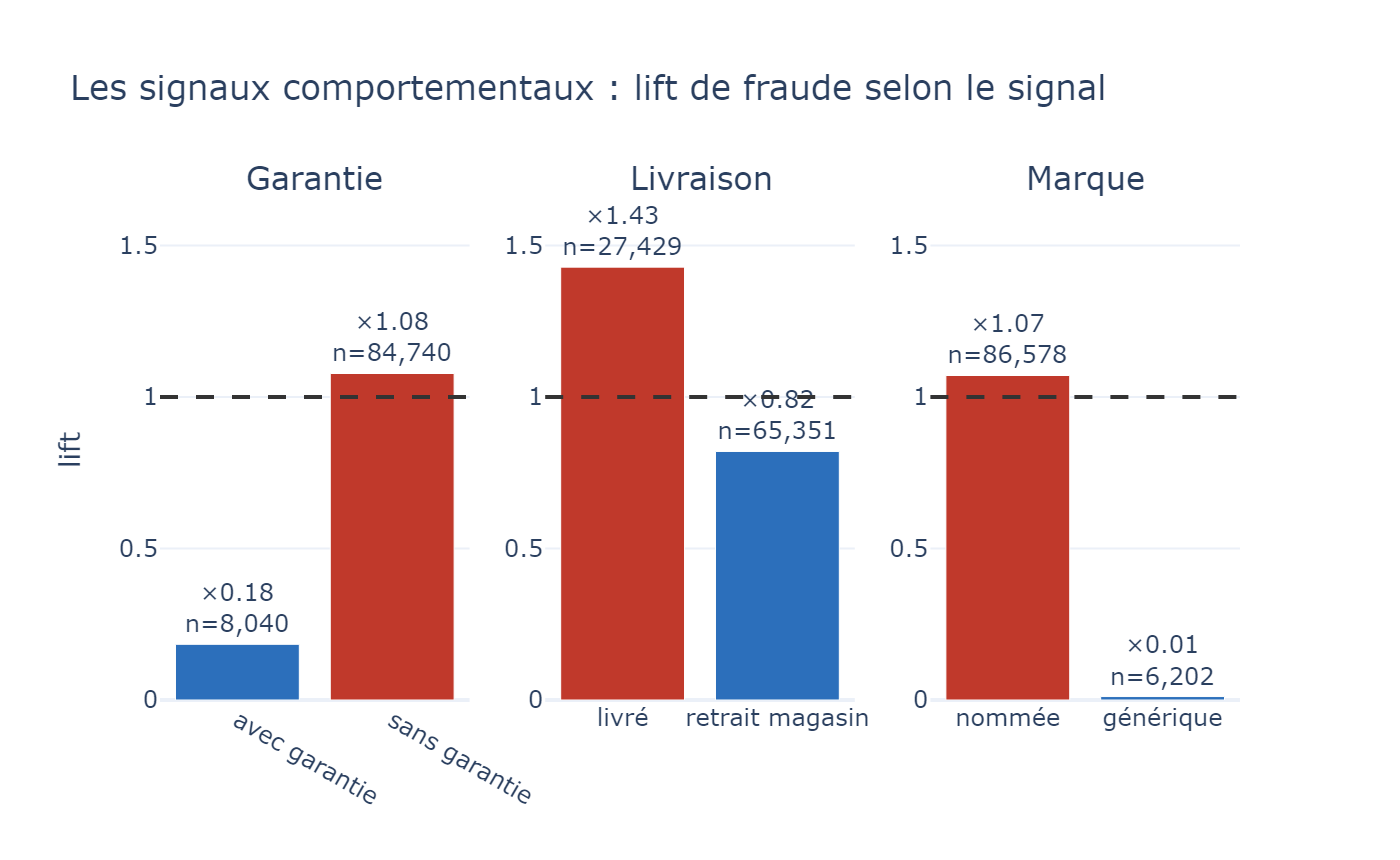

In [13]:
generic = d.dom_make.str.contains("RETAILER", na=False) | d.dom_make.isin(["UNBRANDED", "NONE"])
signaux = {
    "Garantie":  {"avec garantie": d.has_warr,  "sans garantie": ~d.has_warr},
    "Livraison": {"livré": d.has_deliv, "retrait magasin": ~d.has_deliv},
    "Marque":    {"nommée": ~generic, "générique": generic},
}
fig = make_subplots(rows=1, cols=3, subplot_titles=list(signaux.keys()), horizontal_spacing=0.07)
for col, (name, groups) in enumerate(signaux.items(), start=1):
    labs, lf, ns = lifts(groups)                       # lifts() défini en C
    colors = ["#c0392b" if v >= 1 else "#2c6fbb" for v in lf]
    fig.add_bar(x=labs, y=lf, marker_color=colors, row=1, col=col, showlegend=False,
                text=[f"×{v:.2f}<br>n={n:,}" for v, n in zip(lf, ns)], textposition="outside")
    fig.add_hline(y=1, line_dash="dash", line_color="#333", row=1, col=col)
for c in (1, 2, 3):
    fig.update_yaxes(range=[0, 1.65], title_text=("lift" if c == 1 else ""), row=1, col=c)
fig.update_layout(template="plotly_white", height=430,
    title="Les signaux comportementaux : lift de fraude selon le signal")
show_fig(fig, "comportement_signaux")

### Ce qu'on voit

- **Garantie : le signal le plus net.** Avec garantie → lift **0,18** (≈ 5× moins
  de fraude) ; sans → 1,08. Le fraudeur **n'assure pas** un bien qu'il ne compte
  pas garder.
- **Livraison** : livré → lift **1,43** ; retrait magasin → 0,82. La fraude a besoin
  d'une **adresse** (pas d'un retrait en magasin, où l'identité est vérifiée).
- **Marque** : générique/sans marque → lift **0,01** (quasi zéro fraude) ; nommée →
  1,07. On revend un iPhone, pas un produit distributeur.

> Nuance : la « marque générique » recoupe largement le **produit** (les génériques
> sont surtout du meuble, déjà peu risqué) : c'est plus un reflet du produit qu'un
> pur signal comportemental. Les deux signaux vraiment **comportementaux** sont la
> garantie et la livraison.


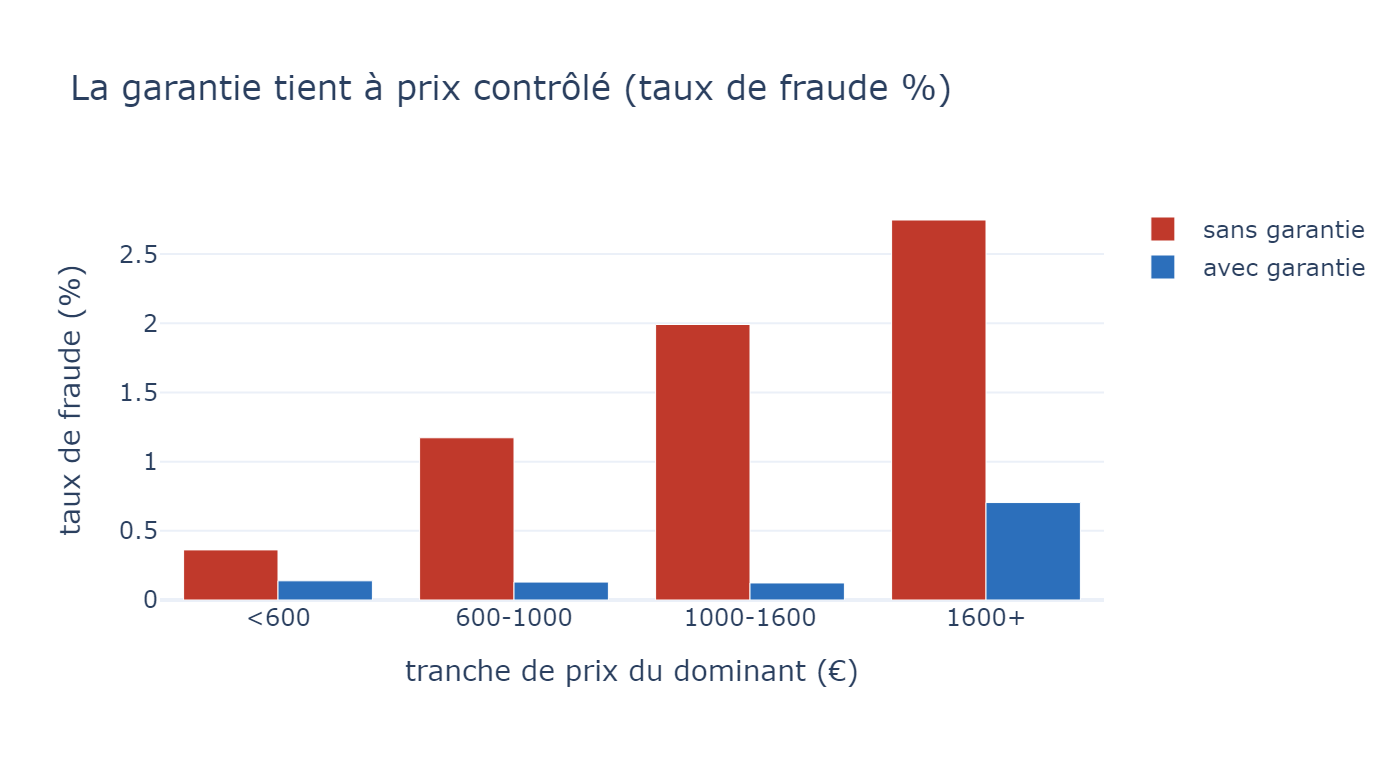

In [14]:
b = pd.cut(d.dom_price, [0, 600, 1000, 1600, np.inf],
           labels=["<600", "600-1000", "1000-1600", "1600+"], right=False)
w = np.where(d.has_warr, "avec garantie", "sans garantie")
t = pd.DataFrame({"b": b, "w": w, "y": d.fraud}).pivot_table("y", "w", "b", aggfunc="mean") * 100
labs = ["<600", "600-1000", "1000-1600", "1600+"]

fig = go.Figure()
for grp, color in [("sans garantie", "#c0392b"), ("avec garantie", "#2c6fbb")]:
    fig.add_bar(x=labs, y=t.loc[grp, labs].values, name=grp, marker_color=color)
fig.update_layout(barmode="group", template="plotly_white", height=380,
    title="La garantie tient à prix contrôlé (taux de fraude %)",
    xaxis_title="tranche de prix du dominant (€)", yaxis_title="taux de fraude (%)")
show_fig(fig, "comportement_garantie_prix")

### La garantie tient-elle vraiment ? (contrôle par le prix)

On pouvait craindre que « pas de garantie » ne soit qu'un reflet du « panier mono »
(vu à la section structure). Ce n'est **pas** le cas : à **chaque tranche de prix**, les paniers **avec
garantie sont bien moins frauduleux**. À 1000–1600 €, **0,12 % (avec) vs 1,99 %
(sans)**, soit **16× moins**, sur des volumes suffisants (n ≈ 2 400).

→ **La garantie est un vrai signal, indépendant du prix.** C'est le signe le plus
direct de l'intention : on ne protège pas un bien qu'on va écouler.

### Bilan

Ces signaux apportent une information **comportementale**, sur un axe distinct du prix et du
produit. Le plus fort, la **garantie**, est confirmé à prix contrôlé. La
**livraison** dit le canal (adresse plutôt que magasin). Ces signaux **s'ajoutent**
à « cher × liquide » pour dessiner le fraudeur type : **un bien unique, cher,
liquide, livré, sans garantie**.


# Synthèse : le portrait-robot de la fraude

### Le fraudeur type

Un panier frauduleux, c'est **un bien unique, cher (~1 250–2 000 €), de nature
liquide** (électronique portable : ordinateur ou téléphone Apple, ou poussette
premium), **livré**, et **sans extension de garantie**. Ce n'est ni de la revente en
volume, ni un abus diffus : c'est le détournement d'**un objet précis, facile à
écouler**.

### Les enseignements, bloc par bloc

- **Le prix** : le risque monte avec le prix (logique de revente) ;
  et l'essentiel de la **perte en euros** est porté par la minorité de gros paniers.
- **Le produit** : électronique **liquide** (ordinateurs, téléphones) + puériculture
  premium ; le téléviseur, cher mais encombrant, est épargné.
- **Prix vs produit (confondants)** : ce n'est ni « Apple » ni « l'électronique » en soi, c'est le
  bien **cher ET liquide**. Prix et liquidité sont deux moteurs **partiellement indépendants** ; la
  marque n'en est que le reflet.
- **La structure** : achat **ciblé** (un seul bien) ; le volume / la quantité est
  *protecteur*.
- **Le comportement** : **sans garantie** (le signal le plus fort, confirmé à prix
  contrôlé) et **livré**.
- **La concentration (SKU)** : fraude **étalée** sur un large éventail de biens chers /
  liquides, pas sur une poignée de SKU.

### Implications pour la modélisation

**À privilégier** :
- le **prix** (dominant et total) et la **catégorie** (électronique liquide vs
  meuble/TV) : le vrai signal est leur **intersection cher × liquide** ;
- les **signaux comportementaux** (garantie et livraison), qui apportent une
  information **indépendante** du prix et du produit.

**À ne pas sur-pondérer** :
- le **volume / la quantité** (pointe dans le **mauvais sens**) ;
- la **marque** seule (surtout un reflet du prix + catégorie) ;
- le **`goods_code`** (aide, mais la fraude est trop étalée pour en faire un signal
  décisif).

**Robustesse & rappels** :
- **train et test ont la même composition** (vérifié sur la catégorie et la marque) → le signal appris
  **transférera** au test ;
- exclure le bloc synthétique **`ABC`** (fait en data quality) et **forcer à 0** ses
  2 paniers du test ;
